The following code cell completes these tasks:

1. Data Preprocessing Part 1:
   a. checks for duplicacy
   b. fills void cells
   c. standardises the column Fault_Type for uniform reverse mapping

2. Data Preprocessing Part 2:
   a. converts hyphens to NaNs and converts them to numeric.
   b. replaces very small or 0 values with epsilon = 0.001
   c. imputes missing gas values using source-specific and adaptive KNN(K Nearest Neighbour).
   d. Creates columns containing classical diagnostic ratios.
   e. performs manual label encoding for better ML practices in future.

3. Manual Fault Analysis
   a. Roger's Ratio Method
   b. Duval's Triangle Method
   c. Accuracy Analysis
   
4. Saves the updated final dataset in a new excel file, ready for ML training and testing operations.

Raw dataset is fed into this code and a cleaned and fully processed dataset is returned.

In [ ]:
# Install & import libraries
!pip install openpyxl
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from google.colab import files

# Upload the Excel file
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Read Excel file and load the dataset into df
df = pd.read_excel(file_name)
df.head()

# -----------------Preprocessing of the Dataset: Part 1-------------------------

# # Remove duplicate rows
# df = df.drop_duplicates()

# # Fill null values in CO and CO2 with "NA"
# for col in ['CO', 'CO2']:
#     if col in df.columns:
#         df[col] = df[col].fillna('NA')

# # Define mapping for Fault_Type to Fault_Class
# mapping = {
#     'PD': ['partial discharge', 'corona discharge', 'pd', 'partial discharges'],
#     'D1': ['low energy discharge', 'low-energy discharge', 'spark discharge', 'd1'],
#     'D2': ['high energy discharge', 'arc discharge', 'Arcing', 'high-energy discharge', 'd2'],
#     'T1': ['low-temperature overheating', 't1'],
#     'T2': ['middle-temperature overheating', 'thermal fault 300-700 deg c', 't2', 'sheet1: t2', 'iec table 5'],
#     'T3': ['high-temperature overheating', 'thermal fault >700 deg c', 't3', 'sheet1: t3'],
#     'Normal': ['ormal', 'background gas']
# }

# # Fill Fault_Class based on Fault_Type (cell by cell)
# def classify_fault_cell(text):
#     if pd.isna(text):
#         return ''
#     txt = ' '.join(str(text).split()).lower()
#     txt = txt.replace('°', 'deg')
#     for fault_class, keywords in mapping.items():
#         for keyword in keywords:
#             if keyword.lower() in txt:
#                 return fault_class
#     return ''

# df['Fault_Class'] = df.apply(
#     lambda row: classify_fault_cell(row['Fault_Type']) if pd.isna(row['Fault_Class']) or str(row['Fault_Class']).strip() == ''
#     else row['Fault_Class'],
#     axis=1
# )

# # Clean Fault_Class for reverse mapping
# df['Fault_Class'] = df['Fault_Class'].apply(lambda x: str(x).strip().upper() if pd.notna(x) else x)

# # Reverse mapping to fill Fault_Type if empty
# reverse_mapping = {
#     'PD': 'Partial Discharge',
#     'D1': 'Spark Discharge',
#     'D2': 'Arc Discharge',
#     'T1': 'Low-temperature overheating',
#     'T2': 'Middle-temperature overheating',
#     'T3': 'High-temperature overheating',
#     'NORMAL': 'Normal'
# }

# df['Fault_Type'] = df.apply(
#     lambda row: reverse_mapping.get(str(row['Fault_Class']).upper(), row['Fault_Type'])
#     if pd.isna(row['Fault_Type']) or str(row['Fault_Type']).strip() == ''
#     else row['Fault_Type'],
#     axis=1
# )

# # Trim all text columns
# for col in df.select_dtypes(include=['object']).columns:
#     df[col] = df[col].apply(lambda x: str(x).strip() if pd.notna(x) else x)


# -----------------Preprocessing of the Dataset: Part 2-------------------------

# Gas columns
gas_cols = ['H2','CH4','C2H6','C2H4','C2H2','CO','CO2']

# Replace hyphens, blanks, spaces with NaN
df[gas_cols] = df[gas_cols].replace(['-', '', ' '], np.nan)

# Convert to numeric
df[gas_cols] = df[gas_cols].apply(pd.to_numeric, errors='coerce')

# Replace zero with epsilon
epsilon = 0.001
df[gas_cols] = df[gas_cols].replace(0, epsilon)


# Source-Specific Adaptive KNN

df_imputed_list = []

for source, group in df.groupby("Source"):
    g = group.copy()
    n = len(g)

    # Adaptive k selection
    if n <= 1:
        for col in gas_cols:
            med = g[col].median()
            g[col] = g[col].fillna(med)
        df_imputed_list.append(g)
        continue

    if n <= 3:
        k = 1
    elif n <= 10:
        k = 2
    elif n > 1000:
        k = 9
    elif n > 300:
        k = 5
    else:
        k = 3

    k = min(k, n - 1)

    print(f"Source: {source}, Rows: {n}, Using k = {k}")

    available_cols = [c for c in gas_cols if c in g.columns]

    X = g[available_cols].values

    imputer = KNNImputer(n_neighbors=k)
    X_new = imputer.fit_transform(X)

    # Avoiding error during column re-assignment
    if X_new.shape[1] == len(available_cols):
        g.loc[:, available_cols] = X_new
    else:
        cols_to_assign = min(X_new.shape[1], len(available_cols))
        g.loc[:, available_cols[:cols_to_assign]] = X_new[:, :cols_to_assign]

    df_imputed_list.append(g)

df = pd.concat(df_imputed_list).sort_index()


# Create classical DGA ratios

df['CH4_H2'] = df['CH4'] / df['H2']
df['C2H6_CH4'] = df['C2H6'] / df['CH4']
df['C2H2_C2H4'] = df['C2H2'] / df['C2H4']
df['C2H4_C2H6'] = df['C2H4'] / df['C2H6']
df['CO2_CO'] = df['CO2'] / df['CO']

# Replace infinite values
df.replace([np.inf, -np.inf], epsilon, inplace=True)


# Manual label encoding

manual_mapping_class = {
    'PD': 0,
    'D1': 1,
    'D2': 2,
    'T1': 3,
    'T2': 4,
    'T3': 5,
    'NORMAL': 6
}

df['Fault_Class_LE'] = df['Fault_Class'].map(manual_mapping_class)


#-----------Fault Analysis using Roger's Ratio and Duval's Triangle-------------

epsilon = 0.001
tolerance = 0.20
min_gas_threshold = 10

def is_low_gas_noise(row):
    total = row[['H2','CH4','C2H6','C2H4','C2H2']].sum()
    return total < min_gas_threshold

# Roger's Ratio Method
def rogers_with_tolerance(row):

    if is_low_gas_noise(row):
        return "LOW GAS"

    R1 = row['CH4_H2']
    R2 = row['C2H2_C2H4']
    R3 = row['C2H4_C2H6']

    def within(value, target):
        return abs(value - target) <= (tolerance * target + epsilon)

    if R1 < 0.1 + tolerance and R2 < 0.1 + tolerance and R3 < 0.2 + tolerance:
        return "PD"

    if R1 < 1 + tolerance and within(R2, 1) and R3 < 3 + tolerance:
        return "D1"

    if R1 > 1 - tolerance and R2 > 1 - tolerance and R3 > 3 - tolerance:
        return "D2"

    if R1 < 0.1 + tolerance and R2 < 0.1 + tolerance and R3 > 1 - tolerance:
        return "T1"

    if R1 < 1 + tolerance and R2 < 1 + tolerance and R3 > 3 - tolerance:
        if row['C2H4'] < 100:
            return "T2"
        else:
            return "T3"

    return "UNKNOWN"

df['Rogers_Fault'] = df.apply(rogers_with_tolerance, axis=1)

# Duval Triangle Method
def duval_with_tolerance(row):

    if is_low_gas_noise(row):
        return "LOW GAS"

    total = row['C2H2'] + row['C2H4'] + row['CH4']
    if total == 0:
        return "UNKNOWN"

    pct_C2H2 = (row['C2H2'] / total) * 100
    pct_C2H4 = (row['C2H4'] / total) * 100
    pct_CH4 = (row['CH4'] / total) * 100

    def near(value, boundary):
        return abs(value - boundary) <= tolerance * boundary + epsilon

    if pct_C2H2 < 4 + 4*tolerance and pct_C2H4 < 10 + 10*tolerance:
        return "PD"

    if pct_CH4 > 98 - 98*tolerance:
        return "T1"

    if pct_C2H4 > 20 - 20*tolerance and pct_CH4 < 50 + 50*tolerance:
        return "T2"

    if pct_C2H4 > 50 - 50*tolerance:
        return "T3"

    if pct_C2H2 > 4 - 4*tolerance and pct_C2H2 < 13 + 13*tolerance:
        return "D1"

    if pct_C2H2 > 13 - 13*tolerance:
        return "D2"

    return "UNKNOWN"

df['Duval_Fault'] = df.apply(duval_with_tolerance, axis=1)

# Comparison with True Class
df['Rogers_vs_FaultClass'] = df.apply(
    lambda row: "Match" if str(row['Rogers_Fault']).upper() == str(row['Fault_Class']).upper()
    else "No Match",
    axis=1
)

df['Duval_vs_FaultClass'] = df.apply(
    lambda row: "Match" if str(row['Duval_Fault']).upper() == str(row['Fault_Class']).upper()
    else "No Match",
    axis=1
)

# Comparison between Roger and Duval
df['Rogers_vs_Duval'] = df.apply(
    lambda row: "Same" if str(row['Rogers_Fault']).upper() == str(row['Duval_Fault']).upper()
    else "Different",
    axis=1
)

# Save the updated dataset to Excel
output_file = "DGA_Dataset_Processed_Final.xlsx"
df.to_excel(output_file, index=False)
files.download(output_file)

print("Downloaded.")

In [ ]:
# Flowchart for the whole Preprocessing and Analysis Process


In [ ]:
                           ┌──────────────────────────┐
                           │        START             │
                           │    Load Dataset          │
                           └───────────┬──────────────┘
                                       │
                                       ▼
                      ┌──────────────────────────────────────┐
                      │  Remove Duplicates & Trim Text        │
                      └───────────┬───────────────────────────┘
                                  │
                                  ▼
            ┌───────────────────────────────────────────────────────┐
            │  Fault_Type → Fault_Class Mapping                     │
            │  • Identify keywords                                   │
            │  • Fill missing Fault_Class                            │
            │  • Reverse-fill missing Fault_Type                     │
            └───────────┬───────────────────────────────────────────┘
                        │
                        ▼
            ┌───────────────────────────────────────────────────────┐
            │  Gas Data Cleaning                                     │
            │  • Replace “-”, blanks → NaN                           │
            │  • Convert to numeric                                  │
            │  • Replace zeros with ε                                │
            └───────────┬───────────────────────────────────────────┘
                        │
                        ▼
    ┌────────────────────────────────────────────────────────────────────────┐
    │  Source-Specific KNN Imputation                                        │
    │  • Group data by Source                                                │
    │  • Adaptive K selection (1, 3, 5, 9...)                                 │
    │  • If column has some values → Source-specific KNN                     │
    │  • If column is fully empty → Replace using Global KNN fallback        │
    └───────────┬────────────────────────────────────────────────────────────┘
                │
                ▼
           ┌─────────────────────────────────────────────────────┐
           │  Create DGA Ratio Features                          │
           │  • CH₄/H₂                                           │
           │  • C₂H₆/CH₄                                         │
           │  • C₂H₂/C₂H₄                                         │
           │  • C₂H₄/C₂H₆                                         │
           │  • CO₂/CO                                            │
           └───────────┬──────────────────────────────────────────┘
                       │
                       ▼
           ┌─────────────────────────────────────────────────────┐
           │  Manual Label Encoding (Fault_Class → Integer)      │
           └───────────┬──────────────────────────────────────────┘
                       │
                       ▼
     ┌────────────────────────────────────────────────────────────────────┐
     │  Classical DGA Fault Diagnosis                                     │
     │                                                                    │
     │  1. Roger’s Ratio Method                                           │
     │     • Use R1, R2, R3                                               │
     │     • Apply IEC thresholds                                         │
     │     • Apply tolerance & low-gas checks                             │
     │                                                                    │
     │  2. Duval Triangle Method                                          │
     │     • Convert gases to % CH₄ / C₂H₄ / C₂H₂                         │
     │     • Apply region conditions                                      │
     │     • Apply tolerance & low-gas checks                             │
     └───────────┬─────────────────────────────────────────────────────────┘
                 │
                 ▼
        ┌────────────────────────────────────────────────────────────┐
        │  Compare Predictions                                       │
        │  • Rogers_Fault vs True Fault_Class                        │
        │  • Duval_Fault vs True Fault_Class                         │
        │  • Rogers_Fault vs Duval_Fault                             │
        │  • Ignore UNKNOWN and LOW GAS                              │
        └───────────┬────────────────────────────────────────────────┘
                    │
                    ▼
        ┌────────────────────────────────────────────────────────────┐
        │  Generate Summary Table                                    │
        │  • Valid predictions only                                  │
        │  • Fault-wise accuracy                                     │
        │  • Method agreement                                        │
        └───────────┬────────────────────────────────────────────────┘
                    │
                    ▼
                ┌───────────────────────────┐
                │            END            │
                │      Save & Export        │
                └───────────────────────────┘

The following Code cell generates a table that assesses the accuracy of manual fault analysis in percentage figures.

1. Fault-wise accuracy.
2. Highest accuracies highlighted with blue background.
3. Accuracies above 40% highlighted with green background.
4. separate table showing extent of agreement(or matching instances) between rogers and duval method results.

In [ ]:
import pandas as pd
from google.colab import files
import time
from openpyxl import load_workbook
from openpyxl.styles import Alignment, Font, PatternFill

# Upload the processed Excel file
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Load into df
df = pd.read_excel(file_name, header=0)

# Predictions to ignore
invalid_preds = ['UNKNOWN', 'LOW GAS']

valid_faults = ['PD','D1','D2','T1','T2','T3','NORMAL']

# ---------------- FAULT-WISE ACCURACY ----------------

faultwise_rows = []

for fault in valid_faults:
    subset = df[
        (df['Fault_Class'] == fault) &
        ~df['Rogers_Fault'].isin(invalid_preds) &
        ~df['Duval_Fault'].isin(invalid_preds)
    ]

    if len(subset) == 0:
        continue

    roger_correct = (subset['Rogers_Fault'] == fault).sum()
    duval_correct = (subset['Duval_Fault'] == fault).sum()

    faultwise_rows.append({
        'Fault Type': fault,
        'Total Samples': len(subset),
        'Rogers Accuracy (%)': round((roger_correct / len(subset)) * 100, 2),
        'Duval Accuracy (%)': round((duval_correct / len(subset)) * 100, 2)
    })

faultwise_table = pd.DataFrame(faultwise_rows)

# ---- Add blank row ----
blank_row = pd.DataFrame([{'Fault Type': '', 'Total Samples': '',
                           'Rogers Accuracy (%)': '', 'Duval Accuracy (%)': ''}])

# ---- Add average row ----
avg_row = pd.DataFrame([{
    'Fault Type': 'AVERAGE',
    'Total Samples': '',
    'Rogers Accuracy (%)': round(faultwise_table['Rogers Accuracy (%)'].mean(), 2),
    'Duval Accuracy (%)': round(faultwise_table['Duval Accuracy (%)'].mean(), 2)
}])

faultwise_table = pd.concat([faultwise_table, blank_row, avg_row], ignore_index=True)

print("=== Fault-wise Accuracy with Average ===")
print(faultwise_table)

# ---------------- ROGERS vs DUVAL AGREEMENT ----------------

agreement_rows = []

for fault in valid_faults:
    subset = df[
        (df['Fault_Class'] == fault) &
        ~df['Rogers_Fault'].isin(invalid_preds) &
        ~df['Duval_Fault'].isin(invalid_preds)
    ]

    if len(subset) == 0:
        continue

    agree_count = (subset['Rogers_Fault'] == subset['Duval_Fault']).sum()

    agreement_rows.append({
        'Fault Type': fault,
        'Rogers–Duval Agreement (%)': round((agree_count / len(subset)) * 100, 2)
    })

agreement_table = pd.DataFrame(agreement_rows)

# ---------------- SAVE TO EXCEL ----------------

summary_file = f"DGA_Faultwise_Summary_{int(time.time())}.xlsx"

with pd.ExcelWriter(summary_file, engine='openpyxl') as writer:
    faultwise_table.to_excel(writer, sheet_name='Faultwise_Accuracy', index=False)
    agreement_table.to_excel(writer, sheet_name='Agreement', index=False)

# ---------------- EXCEL FORMATTING ----------------

wb = load_workbook(summary_file)
ws = wb['Faultwise_Accuracy']

cyan_fill = PatternFill(start_color='B7DEE8', end_color='B7DEE8', fill_type='solid')
green_fill = PatternFill(start_color='C6EFCE', end_color='C6EFCE', fill_type='solid')
bold_font = Font(bold=True)

# Find max values (excluding AVERAGE row)
data_rows = ws.iter_rows(min_row=2, max_row=ws.max_row-2, min_col=3, max_col=4)
rogers_vals = []
duval_vals = []

for row in data_rows:
    if isinstance(row[0].value, (int, float)):
        rogers_vals.append(row[0].value)
    if isinstance(row[1].value, (int, float)):
        duval_vals.append(row[1].value)

max_rogers = max(rogers_vals)
max_duval = max(duval_vals)

# Apply coloring
for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
    for cell in row:
        cell.alignment = Alignment(wrap_text=True, vertical='center')

    # Rogers column
    r_cell = row[2]
    d_cell = row[3]

    if isinstance(r_cell.value, (int, float)):
        if r_cell.value == max_rogers:
            r_cell.fill = cyan_fill
        elif r_cell.value >= 40:
            r_cell.fill = green_fill

    if isinstance(d_cell.value, (int, float)):
        if d_cell.value == max_duval:
            d_cell.fill = cyan_fill
        elif d_cell.value >= 40:
            d_cell.fill = green_fill

# Bold AVERAGE row
for cell in ws[ws.max_row]:
    cell.font = bold_font

# Auto column width
for col in ws.columns:
    max_len = max(len(str(cell.value)) if cell.value else 0 for cell in col)
    ws.column_dimensions[col[0].column_letter].width = max_len + 3

wb.save(summary_file)

files.download(summary_file)

print("Formatted fault-wise summary with highlighted accuracies downloaded.")

In [ ]:
Decision Tree

In [ ]:
# ---------------- DECISION TREE MODEL TRAINING ----------------

import pandas as pd
import numpy as np
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Upload the FINAL processed dataset
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

'''# ---------------- REMOVE UNKNOWN / LOW GAS ROWS ----------------

# if 'Rogers_Fault' in df.columns:
#     df = df[~df['Rogers_Fault'].isin(['UNKNOWN','LOW GAS'])]

# if 'Duval_Fault' in df.columns:
#     df = df[~df['Duval_Fault'].isin(['UNKNOWN','LOW GAS'])]

# df = df.reset_index(drop=True)'''

# ---------------- DEFINE FEATURES ----------------

feature_cols = [
    'H2','CH4','C2H6','C2H4','C2H2','CO','CO2',
    'CH4_H2','C2H6_CH4','C2H2_C2H4','C2H4_C2H6','CO2_CO'
]

X = df[feature_cols]
y = df['Fault_Class_LE']

# ---------------- TRAIN-TEST SPLIT ----------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---------------- TRAIN DECISION TREE ----------------

model = DecisionTreeClassifier(
    max_depth=10,              # controls overfitting
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

# ---------------- PREDICTIONS ----------------

y_pred = model.predict(X_test)

# ---------------- EVALUATION ----------------

accuracy = accuracy_score(y_test, y_pred)
print("\nTest Accuracy:", round(accuracy * 100, 2), "%")

# Reverse label mapping
label_map = {
    0: 'PD',
    1: 'D1',
    2: 'D2',
    3: 'T1',
    4: 'T2',
    5: 'T3',
    6: 'NORMAL'
}

# Convert numeric labels to names
y_test_named = y_test.map(label_map)
y_pred_named = pd.Series(y_pred).map(label_map)

print("\nClassification Report:\n")
print(classification_report(y_test_named, y_pred_named))

# ---------------- CONFUSION MATRIX ----------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ---------------- FEATURE IMPORTANCE ----------------

importances = model.feature_importances_

feat_imp = pd.Series(importances, index=feature_cols)
feat_imp = feat_imp.sort_values()

plt.figure(figsize=(8,6))
feat_imp.plot(kind='barh')
plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance Score")
plt.show()

#Plot

from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model,
          feature_names=feature_cols,
          class_names=list(label_map.values()),
          filled=True,
          max_depth=3)
plt.show()

# ------------------ SAVING THE MODEL -----------------

import joblib
joblib.dump(model, "decision_tree_model.pkl")

# saving a local copy (optional)
'''from google.colab import files
files.download("decision_tree_model.pkl")'''

Random Forest

Saving DGA_Dataset_Processed_Final (2).xlsx to DGA_Dataset_Processed_Final (2).xlsx

Test Accuracy: 90.11 %

Classification Report:

              precision    recall  f1-score   support

          D1       0.85      0.95      0.89        76
          D2       0.96      0.83      0.89        82
      NORMAL       0.98      0.97      0.97       148
          PD       0.93      0.97      0.95        38
          T1       0.72      0.64      0.68        33
          T2       0.80      0.74      0.77        43
          T3       0.88      0.94      0.91       126

    accuracy                           0.90       546
   macro avg       0.87      0.86      0.87       546
weighted avg       0.90      0.90      0.90       546



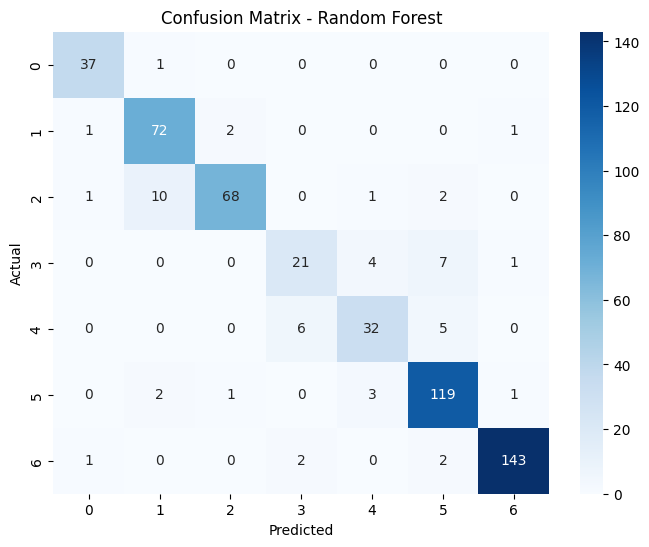

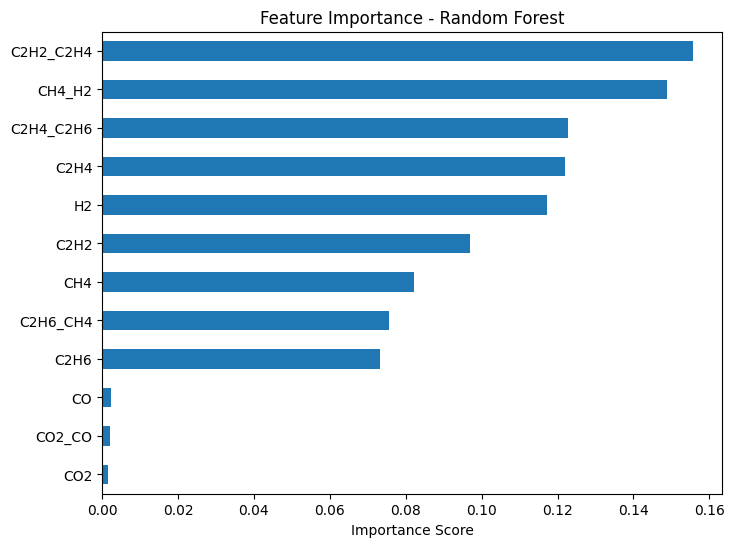

'from google.colab import files\nfiles.download("random_forest_model.pkl")'

In [ ]:
# ---------------- RANDOM FOREST MODEL TRAINING ----------------

import pandas as pd
import numpy as np
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Upload the FINAL processed dataset
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

# ---------------- REMOVE UNKNOWN / LOW GAS ROWS ----------------
# (If these columns exist, otherwise it will skip safely)

# if 'Rogers_Fault' in df.columns:
    # df = df[~df['Rogers_Fault'].isin(['UNKNOWN','LOW GAS'])]

# if 'Duval_Fault' in df.columns:
#     df = df[~df['Duval_Fault'].isin(['UNKNOWN','LOW GAS'])]

# df = df.reset_index(drop=True)

# ---------------- DEFINE FEATURES ----------------

feature_cols = [
    'H2','CH4','C2H6','C2H4','C2H2','CO','CO2',
    'CH4_H2','C2H6_CH4','C2H2_C2H4','C2H4_C2H6','CO2_CO'
]

X = df[feature_cols]
y = df['Fault_Class_LE']

# ---------------- TRAIN-TEST SPLIT ----------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---------------- TRAIN RANDOM FOREST ----------------

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

# ---------------- PREDICTIONS ----------------

y_pred = model.predict(X_test)

# ---------------- EVALUATION ----------------

accuracy = accuracy_score(y_test, y_pred)
print("\nTest Accuracy:", round(accuracy * 100, 2), "%")

# Reverse label mapping
label_map = {
    0: 'PD',
    1: 'D1',
    2: 'D2',
    3: 'T1',
    4: 'T2',
    5: 'T3',
    6: 'NORMAL'
}

# Convert numeric labels to names
y_test_named = y_test.map(label_map)
y_pred_named = pd.Series(y_pred).map(label_map)

print("\nClassification Report:\n")
print(classification_report(y_test_named, y_pred_named))

# ---------------- CONFUSION MATRIX ----------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ---------------- FEATURE IMPORTANCE ----------------

importances = model.feature_importances_

feat_imp = pd.Series(importances, index=feature_cols)
feat_imp = feat_imp.sort_values()

plt.figure(figsize=(8,6))
feat_imp.plot(kind='barh')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

# ------------------ SAVING THE MODEL -----------------
#saving in the notebook
import joblib
joblib.dump(model, "random_forest_model.pkl")

# saving a local copy(not needed for now)
'''from google.colab import files
files.download("random_forest_model.pkl")'''

XGBoost

Saving DGA_Dataset_Processed_Final (2).xlsx to DGA_Dataset_Processed_Final (2) (1).xlsx


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:02:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Test Accuracy: 89.93 %

Classification Report:

              precision    recall  f1-score   support

          D1       0.86      0.92      0.89        76
          D2       0.93      0.84      0.88        82
      NORMAL       0.97      0.95      0.96       148
          PD       0.93      0.97      0.95        38
          T1       0.70      0.58      0.63        33
          T2       0.85      0.77      0.80        43
          T3       0.88      0.97      0.92       126

    accuracy                           0.90       546
   macro avg       0.87      0.86      0.86       546
weighted avg       0.90      0.90      0.90       546



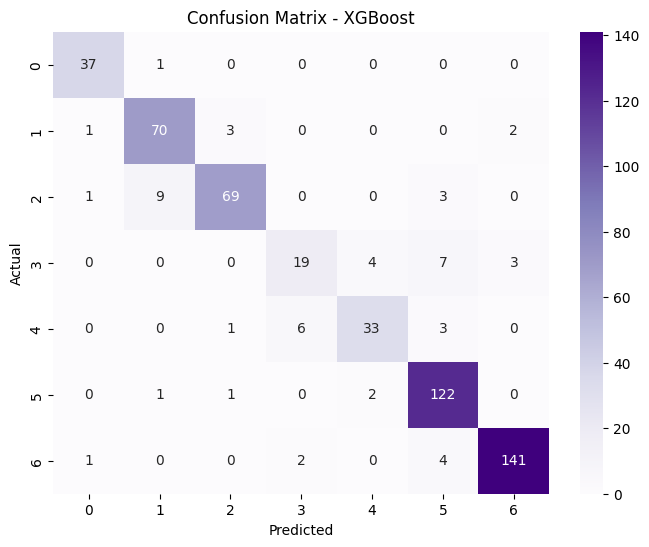

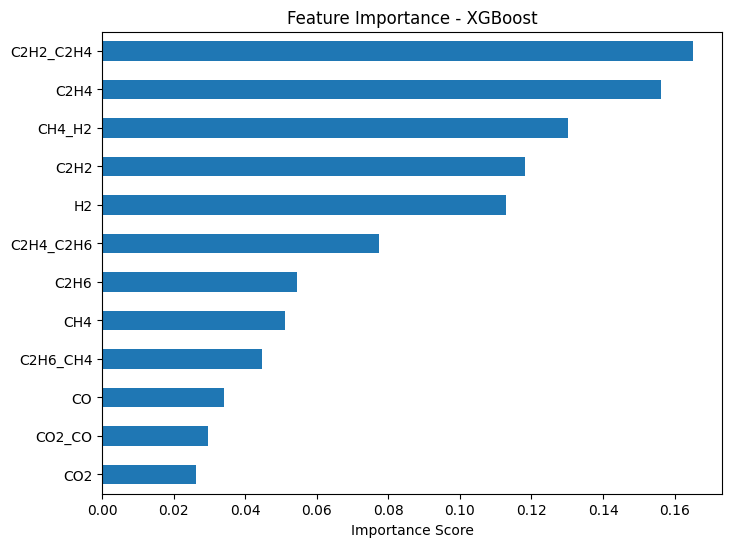

['xgboost_model.pkl']

In [ ]:
# ---------------- XGBOOST MODEL TRAINING ----------------

import pandas as pd
import numpy as np
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Install XGBoost (only first time)
!pip install xgboost

from xgboost import XGBClassifier

# Upload the FINAL processed dataset
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

# ---------------- REMOVE UNKNOWN / LOW GAS ROWS ----------------

# if 'Rogers_Fault' in df.columns:
#     df = df[~df['Rogers_Fault'].isin(['UNKNOWN','LOW GAS'])]

# if 'Duval_Fault' in df.columns:
#     df = df[~df['Duval_Fault'].isin(['UNKNOWN','LOW GAS'])]

# df = df.reset_index(drop=True)

# ---------------- DEFINE FEATURES ----------------

feature_cols = [
    'H2','CH4','C2H6','C2H4','C2H2','CO','CO2',
    'CH4_H2','C2H6_CH4','C2H2_C2H4','C2H4_C2H6','CO2_CO'
]

X = df[feature_cols]
y = df['Fault_Class_LE']

# ---------------- TRAIN-TEST SPLIT ----------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---------------- TRAIN XGBOOST ----------------

model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.2,
    reg_alpha=0.5,
    reg_lambda=1.5,
    objective='multi:softprob',
    num_class=7,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

model.fit(X_train, y_train)

# ---------------- PREDICTIONS ----------------

y_pred = model.predict(X_test)

# ---------------- EVALUATION ----------------

accuracy = accuracy_score(y_test, y_pred)
print("\nTest Accuracy:", round(accuracy * 100, 2), "%")

# Reverse label mapping
label_map = {
    0: 'PD',
    1: 'D1',
    2: 'D2',
    3: 'T1',
    4: 'T2',
    5: 'T3',
    6: 'NORMAL'
}

# Convert numeric labels to names
y_test_named = y_test.map(label_map)
y_pred_named = pd.Series(y_pred).map(label_map)

print("\nClassification Report:\n")
print(classification_report(y_test_named, y_pred_named))

# ---------------- CONFUSION MATRIX ----------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ---------------- FEATURE IMPORTANCE ----------------

importances = model.feature_importances_

feat_imp = pd.Series(importances, index=feature_cols)
feat_imp = feat_imp.sort_values()

plt.figure(figsize=(8,6))
feat_imp.plot(kind='barh')
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.show()

# ------------------ SAVING THE MODEL -----------------

import joblib
joblib.dump(model, "xgboost_model.pkl")

Interactive Fault Prediction

In [ ]:
# ---------------- INTERACTIVE FAULT PREDICTION ----------------

import joblib
import numpy as np
import pandas as pd

# Load trained model
model = joblib.load("random_forest_model.pkl")

# Feature columns (must match training order exactly)
feature_cols = [
    'H2','CH4','C2H6','C2H4','C2H2','CO','CO2',
    'CH4_H2','C2H6_CH4','C2H2_C2H4','C2H4_C2H6','CO2_CO'
]

# Reverse label mapping
label_map = {
    0: 'PD',
    1: 'D1',
    2: 'D2',
    3: 'T1',
    4: 'T2',
    5: 'T3',
    6: 'NORMAL'
}

print("\nEnter Gas Values (in ppm):")

H2 = float(input("H2: "))
CH4 = float(input("CH4: "))
C2H6 = float(input("C2H6: "))
C2H4 = float(input("C2H4: "))
C2H2 = float(input("C2H2: "))
CO = float(input("CO: "))
CO2 = float(input("CO2: "))

epsilon = 0.001

# Avoid division by zero
H2 = H2 if H2 != 0 else epsilon
CH4 = CH4 if CH4 != 0 else epsilon
C2H6 = C2H6 if C2H6 != 0 else epsilon
C2H4 = C2H4 if C2H4 != 0 else epsilon
CO = CO if CO != 0 else epsilon

# Compute ratios
CH4_H2 = CH4 / H2
C2H6_CH4 = C2H6 / CH4
C2H2_C2H4 = C2H2 / C2H4
C2H4_C2H6 = C2H4 / C2H6
CO2_CO = CO2 / CO

# Create input dataframe
input_data = pd.DataFrame([[H2, CH4, C2H6, C2H4, C2H2, CO, CO2,
                            CH4_H2, C2H6_CH4, C2H2_C2H4, C2H4_C2H6, CO2_CO]],
                          columns=feature_cols)

# Predict
prediction = model.predict(input_data)[0]
predicted_fault = label_map[prediction]

print("\nPredicted Fault Type:", predicted_fault)


Enter Gas Values (in ppm):
H2: 78
CH4: 20
C2H6: 11
C2H4: 13
C2H2: 28
CO: 0
CO2: 0

Predicted Fault Type: D1
